In [1]:
from pathlib import Path
import os, pickle
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
def _safe_ratio(num, den):
    return float(num) / float(den) if den > 0 else 0.0

def _masked_mean_time(x_T2, mask_T, eps=1e-12):
    # x_T2: [T,2], mask_T: [T] in {0,1}
    cnt = mask_T.sum().clamp_min(1.0)
    s = (x_T2 * mask_T.unsqueeze(-1)).sum(dim=0)
    return s / cnt

def _denorm_xy(xy):
    # assumes pos_mean, pos_std on device
    return xy * pos_std + pos_mean

In [3]:
from matplotlib.path import Path
try:
    from shapely.geometry import Polygon
    from shapely.ops import unary_union
    _HAS_SHAPELY = True
except Exception:
    _HAS_SHAPELY = False

# ---- camera params (match your CARLA setup) ----
_CAM_W, _CAM_H = 1280, 720
_CAM_HFOV_DEG = 120.0
_CAM_LIST = [
    dict(x=-60, y=24, z=10, pitch=-60, yaw=0,   roll=0),
    dict(x=-40, y=24, z=10, pitch=-60, yaw=180, roll=0),
    dict(x=-50, y=30, z=10, pitch=-60, yaw=270, roll=0),
    dict(x=-50, y=10, z=10, pitch=-60, yaw=90,  roll=0),
]

def _Rz(a):
    a=np.radians(a); c,s=np.cos(a),np.sin(a)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])
def _Ry(a):
    a=np.radians(a); c,s=np.cos(a),np.sin(a)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]])
def _Rx(a):
    a=np.radians(a); c,s=np.cos(a),np.sin(a)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]])

def _cam_dirs_boundary(hfov_deg, H, W, n=96):
    vfov_deg = np.degrees(2*np.arctan(np.tan(np.radians(hfov_deg/2.0))*(H/W)))
    th = np.tan(np.radians(hfov_deg/2.0))
    tv = np.tan(np.radians(vfov_deg/2.0))
    u_top    = np.linspace(-1, 1, n); v_top    = np.full_like(u_top, -1)
    u_right  = np.full(n, 1);        v_right  = np.linspace(-1, 1, n)
    u_bottom = np.linspace( 1,-1, n);v_bottom = np.full_like(u_bottom, 1)
    u_left   = np.full(n, -1);       v_left   = np.linspace( 1,-1, n)
    u = np.concatenate([u_top,u_right,u_bottom,u_left])
    v = np.concatenate([v_top,v_right,v_bottom,v_left])
    d = np.stack([np.ones_like(u), u*th, v*tv], axis=1)
    return d/np.linalg.norm(d,axis=1,keepdims=True)

def _footprint_xy(cam, hfov_deg, H, W, n=96):
    # Unreal/CARLA: world R = Rz(yaw) @ Ry(-pitch) @ Rx(roll)
    R = _Rz(cam["yaw"]) @ _Ry(-cam["pitch"]) @ _Rx(cam["roll"])
    O = np.array([cam["x"], cam["y"], cam["z"]], dtype=float)
    rays = (_R := R) @ _cam_dirs_boundary(hfov_deg, H, W, n).T
    rays = rays.T
    dz = rays[:,2]
    valid = dz < -1e-6
    if not np.any(valid):
        return np.empty((0,2))
    t = -O[2] / dz[valid]
    P = O + rays[valid] * t[:,None]
    return P[:, :2]

def _build_fov_union():
    polys_xy = [_footprint_xy(c, _CAM_HFOV_DEG, _CAM_H, _CAM_W) for c in _CAM_LIST]
    non_empty = [p for p in polys_xy if len(p)>0]
    if not non_empty:
        return dict(mode="none")
    if _HAS_SHAPELY:
        U = unary_union([Polygon(p) for p in non_empty])
        rings = []
        if U.geom_type == "Polygon":
            rings.append(np.c_[np.array(U.exterior.xy).T])
        else:
            for g in U.geometries:
                rings.append(np.c_[np.array(g.exterior.xy).T])
        return dict(mode="poly", rings=rings)
    # raster fallback
    all_pts = np.vstack(non_empty)
    xmin,xmax = all_pts[:,0].min(), all_pts[:,0].max()
    ymin,ymax = all_pts[:,1].min(), all_pts[:,1].max()
    S = 800
    xs = np.linspace(xmin, xmax, S); ys = np.linspace(ymin, ymax, S)
    XX,YY = np.meshgrid(xs, ys)
    union_mask = np.zeros_like(XX, dtype=bool)
    for P in non_empty:
        union_mask |= Path(P).contains_points(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    return dict(mode="mask", XX=XX, YY=YY, M=union_mask)

_FOV_BOUNDARY = _build_fov_union()

def _draw_fov_union(ax, lw=3.0, color="k"):
    m = _FOV_BOUNDARY
    if m["mode"] == "poly":
        for ring in m["rings"]:
            ax.plot(ring[:,0], ring[:,1], color=color, linewidth=lw, zorder=0)
    elif m["mode"] == "mask":
        ax.contour(m["XX"], m["YY"], m["M"].astype(float), levels=[0.5],
                   colors=color, linewidths=lw, zorder=0)
    # else: nothing to draw

In [4]:
N_plot = 15             # number of validation samples to visualize
# main_dir = "tensors"       # where tensors live

# dataset_name = "bw10_delay0_jitter0_loss0"
# dataset_name = "bw10_delay20_jitter5_loss0"
dataset_name = "bw30_delay0_jitter0_loss0"
# dataset_name = "bw30_delay20_jitter5_loss0"
# dataset_name = "encrypted_delay20_jitter5_loss0"
# dataset_name = "unencrypted_delay20_jitter5_loss0"

# dataset_name = "bw50_delay0_jitter0_loss0"
# dataset_name = "bw50_delay20_jitter5_loss0"
# dataset_name = "bw100_delay0_jitter0_loss0"
# dataset_name = "bw100_delay20_jitter5_loss0"
# dataset_name = "bw1000_delay0_jitter0_loss0"
# dataset_name = "bw1000_delay20_jitter5_loss0"

super_name = "seed1_learned"

main_dir = f"tensors/seed1/{dataset_name}"       
save_dir = f"saved_models/{super_name}/{dataset_name}"  # where model .pth files live

In [5]:
# Parameters
E = 1010 # Number of total videos
G = 47 # GOP per video
N = 4 # Number of nodes
T = 10 # GOP length

T_max = 470 # Max length of the input stream

T_in = 40 # Number of frames to the transformer
T_stride = 5 # Slide by how many frames for each 
N_out = 1 # Outputs per each window of W_in frames (always 1 here)
T_avg = 10 # Number frames to be used for ground truth FoV and pos generation

D = 128 # Hidden dimension of the transformer

# These parameters are for deciding whether a segment should have a position estimation or not
tau = 0.5 # p_hat threshold to say vehicle is in the FOV
T_min = T_avg*(tau) # Number of frames in a segment required for position estimation

num_heads=4
depth=8
drop_prob=0.0
fov_min = 3

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda:0


In [6]:
# Base Transformer
class StateTransformer(nn.Module):
    def __init__(self, num_frames = 50, num_nodes = 4, embed_dim = 32, num_heads=4, depth=2, drop_prob=0.1):
        '''
            num_frames: Number of frames (packets, time steps) in the input
            num_nodes: number of gray nodes in the input
            embed_dim: hidden dimension of the transformer
            num_heads: number of heads in the transformer
            depth: depth of the transformer
            drop_prob: Dropout parameter for the transformer
        '''
        super(StateTransformer, self).__init__()

        self.num_frames = num_frames
        self.num_nodes = num_nodes
        self.hidden_dim = embed_dim
        
        self.packet_projector = nn.Linear(1, embed_dim)
        self.state_tok_projector = nn.Linear(embed_dim, embed_dim)
        
        # Position embedding for every packet/frame in the input
        self.frame_idx_embedding  = nn.Parameter(torch.empty(1, num_frames+1, embed_dim)) 
        # Embedding token for nodes
        self.node_idx_embeding  = nn.Parameter(torch.empty(1, num_nodes+1, embed_dim))

        # Normalize the state token 
        self.stateLN = nn.LayerNorm(embed_dim)
        
        # Initialize the tokens
        nn.init.trunc_normal_(self.frame_idx_embedding, std=0.02)
        nn.init.trunc_normal_(self.node_idx_embeding, std=0.02)
        
        # Encoder network
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=4*embed_dim, norm_first=False, batch_first=True, dropout=drop_prob), num_layers=depth)
        
    def forward(self, packet_input, state = None):
        # packet_input is of shape [B, N, T_eff] (Batch, Node Count, Number of frames)
        # state is of shape [B,D] (None at the beginning of video)
        
        # !!! If packet is 2D, (single batch) expand the tensor !!!
        if packet_input.ndim == 2:
            packet_input = packet_input.unsqueeze(0) 
            if state is not None:
                state = state.unsqueeze(0) 
        else:
            packet_input = packet_input
        
        B, N, T_eff = packet_input.shape
        
        packet_input = packet_input.reshape(B*N*T_eff,1)
        packet_input = packet_input.float() 
        packet_tok = self.packet_projector(packet_input) # output of shape [B*N*T_eff,D]
        packet_tok = packet_tok.reshape(B,N,T_eff,self.hidden_dim) # shape (B,N,T_eff,D)
        
        # Node embedding
        node_embed   = self.node_idx_embeding[0, 1:, :]  # [N,D]
        # Repeat for every batch and time step
        node_embed = node_embed.unsqueeze(0).unsqueeze(2) # (1, N, 1, D)
        node_embed = node_embed.repeat(B, 1, T_eff, 1) # (B, N, T_eff, D)
        
        # add node embedding
        packet_tok = packet_tok + node_embed
        
        # Frame index embedding
        frame_embed = self.frame_idx_embedding[0, 1:(T_eff+1), :]  # (T_eff, D)
        frame_embed = frame_embed.unsqueeze(0).unsqueeze(0)   # (1, 1, T_eff, D)
        frame_embed = frame_embed.repeat(B,N,1,1)           # (B, N, T_eff, D)
        
        # add frame (time step) embedding
        packet_tok = packet_tok + frame_embed
        
        # reshape the packet token to (B,N*T_eff,D)
        packet_tok = packet_tok.reshape(B,T_eff*N,self.hidden_dim)

        # Get the state token 
        if state is None:
            state_tok = torch.zeros(B, self.hidden_dim,
                                 dtype=packet_input.dtype, device=packet_input.device)
        else:
            state_tok = self.state_tok_projector(state)

        # Normalize and add embeddings
        state_tok = self.stateLN(state_tok)
        state_tok_embed = self.node_idx_embeding[0, 0, :] + self.frame_idx_embedding[0, 0, :] 
        state_tok = state_tok + ((state_tok_embed).repeat(B, 1))
        
        # append the state tokens on top of packet tokens for every sample in the batch
        transformer_input = torch.cat([state_tok.unsqueeze(1),packet_tok],dim=1)
        
        out = self.transformer(transformer_input) # input, output shape (B, (T_eff*N)+1, D) 
        out_gops = out[:,1:,:] # output for GOPs, shape (B,N*T_eff,D)
        out_state_tok = out[:,0,:] # (B,D)
                
        return out_state_tok # shape (B,W,D), (B,D)

class SimpleMLP(nn.Module):
    def __init__(self,input_dim = 40, hidden_dims = [256,128,64],output_dim = 2):
        super(SimpleMLP, self).__init__()

        layers = []
        
        # Add input layer
        layers.append(nn.Linear(input_dim, hidden_dims[0],bias=True))
        layers.append(nn.LayerNorm(hidden_dims[0]))
        layers.append(nn.GELU())

        # Add hidden layers dynamically
        for i in range(len(hidden_dims) - 1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1],bias=True))
            layers.append(nn.LayerNorm(hidden_dims[i+1]))
            layers.append(nn.GELU())

        # Use nn.ModuleList to register layers
        self.layers = nn.ModuleList(layers)

        # Layers for position and velocity estimation
        self.pos_layer = nn.Linear(hidden_dims[-1], output_dim, bias=True)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        
        out = self.pos_layer(x)
            
        return out
        

In [7]:
with open("val_idx.pkl", "rb") as f:
    val_idx = pickle.load(f)  # Tensor or numpy array
val_idx = torch.as_tensor(val_idx)

In [8]:
def _maybe_to_torch(x):
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x)
    return x

# norm_frame_sizes = torch.load(os.path.join(main_dir, "normalized_frames_tensor.pt"), map_location="cpu")

# import the special learned frame sizes
norm_frame_sizes = torch.load(f"/home/zanoria/IoBT/gray_assets/zanoria/carla/grouping_packets/learning_method/checkpoints/{dataset_name}/learned_grouped_tensor_normalized.pkl", map_location="cpu")
norm_frame_sizes = norm_frame_sizes[:,1:,:,:]

norm_position    = torch.load(os.path.join(main_dir, "normalized_position_tensor.pt"), map_location="cpu")
norm_velocity    = torch.load(os.path.join(main_dir, "normalized_velocity_tensor.pt"), map_location="cpu")
fov_values       = torch.load(os.path.join(main_dir, "in_n_out_gt_tensor.pt"), map_location="cpu")
fov_values = fov_values[:,:,10:]
meta_data_tensor = torch.load(os.path.join(main_dir, "meta_data_tensor.pt"), map_location="cpu")

# some of these might be numpy arrays depending on how saved
fov_values = _maybe_to_torch(fov_values)



In [9]:
# Reshape the tensors 
norm_frame_sizes = torch.reshape(norm_frame_sizes, (E,G,T,N)) # [E,G,T,N]
norm_position = torch.reshape(norm_position, (E,G,T,3)) # [E,G,T,3]
fov_values = torch.reshape(fov_values, (E,N+1,G,T)) # [E,G,2]

# Drop the first GoP
# norm_frame_sizes = norm_frame_sizes[:,1:,:,:]
# norm_position = norm_position[:,1:,:,:]
# fov_values = fov_values[:,:,1:,:]

E, G, T, N = norm_frame_sizes.shape

# 0/1 binary visibility for all cameras 1 if even one camera sees one vertex of the bounding box
fov_whole = fov_values[:,0,:,:] 

norm_frame_sizes = norm_frame_sizes.permute(0,3,1,2) # [E,N,G,T]
norm_frame_sizes = norm_frame_sizes.reshape(E,N,G*T) # [E,N,G*T]
norm_position = norm_position.reshape(E,G*T,3) # [E,G*T,3]
fov_whole = fov_whole.reshape(E,G*T) # [E,G*T]
# print(norm_position.shape)

# Update G
G = norm_frame_sizes.shape[1]
print(f"G after dropping first: {G}")

# Construct validation views (same slicing logic as training)
packet_tensor_val = norm_frame_sizes[val_idx]                 # [E_val, G, T, N]
pos_tensor_val    = norm_position[val_idx, :, :2]          # [E_val, G, T, 2]
fov_tensor_val    = fov_whole[val_idx]                    # [E_val, G, T]  (binary whole-seq channel)

print(packet_tensor_val.shape)
print(pos_tensor_val.shape)
print(fov_tensor_val.shape)

G after dropping first: 4
torch.Size([110, 4, 470])
torch.Size([110, 470, 2])
torch.Size([110, 470])


In [10]:
pos_mean = torch.tensor([-51.13490676879883, 22.818683624267578], dtype=torch.float32)
pos_std  = torch.tensor([20.726255416870117, 20.42306900024414], dtype=torch.float32)

pos_mean = pos_mean.to(device)
pos_std  = pos_std.to(device)

In [11]:
transformer_model = StateTransformer(num_frames = T_in, num_nodes = N, embed_dim = D, 
                    num_heads=num_heads, depth=depth, drop_prob=drop_prob).to(device)

input_dim = D
hidden_dims = [input_dim,input_dim//2,input_dim//4]
FOV_output_dim = 1
FOV_predictor_model = SimpleMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=FOV_output_dim).to(device)
pos_predictor_model = SimpleMLP(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=2).to(device)


transformer_model.load_state_dict(torch.load(os.path.join(save_dir, "transformer.pt"), map_location=device))
FOV_predictor_model.load_state_dict(torch.load(os.path.join(save_dir, "fov_head.pt"), map_location=device))
pos_predictor_model.load_state_dict(torch.load(os.path.join(save_dir, "pos_head.pt"), map_location=device))

transformer_model.eval()
FOV_predictor_model.eval()
pos_predictor_model.eval()

SimpleMLP(
  (layers): ModuleList(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (8): GELU(approximate='none')
  )
  (pos_layer): Linear(in_features=32, out_features=2, bias=True)
)

In [12]:
import os, math, numpy as np, torch, matplotlib.pyplot as plt

# ---------- config ----------
PLOTS_DIR = f"val_plots/{super_name}/{dataset_name}"
os.makedirs(PLOTS_DIR, exist_ok=True)
RNG_SEED = 42  # set None for non-deterministic sampling

# ---------- helpers ----------
def _safe_ratio(num, den): return float(num) / float(den) if den > 0 else 0.0
def _fmt_pct(r): return "n/a" if (r is None or not math.isfinite(r)) else f"{100.0*r:.1f}%"
def _masked_mean_time(x_T2, mask_T):
    cnt = mask_T.sum().clamp_min(1.0)
    return (x_T2 * mask_T.unsqueeze(-1)).sum(dim=0) / cnt
def _denorm_xy(xy): return xy * pos_std + pos_mean

# ----------------------------
# Per-sample windowed pass
# ----------------------------
@torch.no_grad()
def eval_one_sample(sample_idx, tau, fov_min):
    """
    Uses the same sliding-window inference as in the training/validation loop:
      for first_idx in range(0, T_max - T_avg + 1, T_stride):
        - input: packet_tensor_val[sample_idx, :, first_idx:first_idx+T_in]  -> [1, N, T_in] (padded if needed)
        - forward: transformer_model(..., prev_state) -> out_state_tok (1,D)
        - heads: FOV_predictor_model(out_state_tok)-> prob, pos_predictor_model(out_state_tok)-> [1,2]
        - compute masks/targets using fov_tensor_val and pos_tensor_val over [first_idx:first_idx+T_avg]
    Aggregates per-window outputs into per-GOP arrays and returns the same dict as before.
    """

    # Load sample tensors (single example)
    # packet: [N, T_max], fov: [T_max] in {-1,0,1}, pos: [T_max,2] (normalized)
    packet_1NT = packet_tensor_val[sample_idx].to(device)      # [N, T_max]
    pos_1T2    = pos_tensor_val[sample_idx].to(device)         # [T_max, 2]
    fov_1T     = fov_tensor_val[sample_idx].to(device)         # [T_max] in {-1,0,1}
    time_code  = int(meta_tensor_val[sample_idx, -1].item())   # e.g., 8..17

    # Number of sliding windows (GOPs)
    total_windows = max(0, (T_max - T_avg) // T_stride + 1)    # same as training schedule

    # Per-window accumulators (shape [G])
    gop_valid_mask = torch.zeros(total_windows, dtype=torch.bool, device=device)
    gt_must_est    = torch.zeros(total_windows, dtype=torch.bool, device=device)
    pred_did_est   = torch.zeros(total_windows, dtype=torch.bool, device=device)

    # Per-window FoV bookkeeping (not strictly needed outside but useful)
    gt_visible_frames = torch.zeros(total_windows, dtype=torch.long,  device=device)

    # Per-window position predictions/GT (for error + plotting)
    pos_pred_win = torch.full((total_windows, 2), float('nan'), device=device)
    gt_pos_xy    = torch.full((total_windows, 2), float('nan'), device=device)

    # Sliding state (same as training)
    prev_state = None

    # A/B tallies + position error
    A=A1=A2=B=B1=B2 = 0
    pos_err_sum = 0.0
    pos_err_cnt = 0

    # Iterate sliding windows identically to training/val
    g = 0
    for first_idx in range(0, T_max - T_avg + 1, T_stride):
        # ----- Build model input [1, N, T_in] with padding as in training -----
        input_packet = packet_1NT[:, first_idx:first_idx+T_in]     # [N, <=T_in]
        T_eff = input_packet.shape[1]
        if T_eff < T_in:
            tmp = torch.zeros(1, N, T_in, device=device, dtype=input_packet.dtype)
            if T_eff > 0:
                tmp[0, :, :T_eff] = input_packet.unsqueeze(0)
            input_packet = tmp
        else:
            input_packet = input_packet.unsqueeze(0)               # [1, N, T_in]

        # ----- Forward (stateful) -----
        out_state_tok = transformer_model(input_packet, prev_state)    # (1, D)
        fov_logits    = FOV_predictor_model(out_state_tok).squeeze(-1) # (1,) → scalar per window
        fov_prob      = torch.sigmoid(fov_logits)[0]                   # float in [0,1]
        preds_pos     = pos_predictor_model(out_state_tok)[0]          # [2]
        prev_state    = out_state_tok.detach()

        # ----- Ground-truth slices over the T_avg next frames -----
        gt_fov_win = fov_1T[first_idx:first_idx+T_avg]                 # [T_avg]
        valid      = (gt_fov_win != -1)                                # [T_avg] bool
        vis        = (gt_fov_win == 1) & valid                         # [T_avg] bool
        invalid_frame_count = (~valid).sum()

        # Window validity mask (same rule as training)
        mask_valid = (invalid_frame_count < T_min)
        gop_valid_mask[g] = mask_valid

        if mask_valid:
            # Ratio & binary visibility target (same as training)
            valid_len = valid.sum().clamp_min(1)
            ratio     = vis.sum().float() / valid_len.float()
            true_visibility = (vis.sum() >= int(T_min))   # VIS_MIN == int(T_min)

            # Prediction decision by tau (same as training)
            fov_est = (fov_prob >= tau)
            pred_did_est[g] = fov_est
            gt_must_est[g]  = true_visibility
            gt_visible_frames[g] = int(vis.sum().item())

            # A/B tallies
            if true_visibility:
                A += 1
                if fov_est: A1 += 1
                else:       A2 += 1
            else:
                B += 1
                if fov_est: B1 += 1
                else:       B2 += 1

            # Store per-window predicted position
            pos_pred_win[g] = preds_pos

            # GT average pos over visible frames (for error + plotting)
            pos_win = pos_1T2[first_idx:first_idx+T_avg]              # [T_avg, 2]
            if vis.any():
                gt_pos_xy[g] = _masked_mean_time(pos_win, vis.float())  # [2]
            else:
                # If no visible frames, leave as NaN (used only when gt_must is False)
                pass

            # Position error on A1 only (true must & predicted did)
            if true_visibility and fov_est:
                # Compare against GT average of visible frames
                # (training val had two flavors; we mirror "oracle-masked" for A1)
                gt_avg = gt_pos_xy[g]
                if torch.isfinite(gt_avg).all():
                    pos_err_sum += float((gt_avg - preds_pos).norm(p=2).item())
                    pos_err_cnt += 1
        else:
            # invalid window → leave masks false/NaN
            pass

        g += 1

    # De-normalize tracks for plotting
    pred_pos_real = _denorm_xy(pos_pred_win)          # [G,2] with NaNs for invalid windows
    # Build GT track used in plot (match earlier semantics):
    # if window valid and >= fov_min visible frames → use GT visible-average,
    # else → use mean of all frames in the window
    gt_track_xy = torch.full((total_windows, 2), float('nan'), device=device)
    g = 0
    for first_idx in range(0, T_max - T_avg + 1, T_stride):
        if gop_valid_mask[g]:
            if gt_visible_frames[g] >= int(fov_min):
                gt_track_xy[g] = gt_pos_xy[g]
            else:
                # mean over the whole window (unmasked) for visualization fallback
                pos_win = pos_1T2[first_idx:first_idx+T_avg]
                if pos_win.numel() > 0:
                    gt_track_xy[g] = pos_win.mean(dim=0)
        g += 1
    gt_track_real = _denorm_xy(gt_track_xy)

    # Final averages
    pos_err_avg = pos_err_sum / max(1, pos_err_cnt)

    return {
        "time_code": time_code,
        "gop_valid": gop_valid_mask, "gt_must": gt_must_est, "pred_did": pred_did_est,
        "A": A, "A1": A1, "A2": A2, "B": B, "B1": B1, "B2": B2,
        "pos_err_sum": pos_err_sum, "pos_err_cnt": pos_err_cnt, "pos_err_avg": pos_err_avg,
        "gt_track_real": gt_track_real, "pred_track_real": pred_pos_real
    }

# ----------------------------
# Plotting (colored GT + saving)
# ----------------------------
def plot_positions_xy_updated(sample_id, time_code, avg_err, gt_xy, pr_xy, gt_must, pred_did, valid_mask, index_start=1, out_dir=PLOTS_DIR):
    gt_xy = gt_xy.detach().cpu().numpy()
    pr_xy = pr_xy.detach().cpu().numpy()
    gt_must = gt_must.detach().cpu().numpy().astype(bool)
    pred_did = pred_did.detach().cpu().numpy().astype(bool)
    valid_mask = valid_mask.detach().cpu().numpy().astype(bool)

    agree = valid_mask & (gt_must == pred_did)
    disagree = valid_mask & (gt_must != pred_did)
    show_pred = valid_mask & pred_did

    plt.figure(figsize=(6,6))

    # --- draw FOV union boundary first (thick line) ---
    _draw_fov_union(plt.gca(), lw=3.0, color="k")

    # GT green = agree, red = disagree
    if agree.any():
        plt.scatter(gt_xy[agree,0], gt_xy[agree,1], s=26, marker='o', c='g', label='GT OK')
    if disagree.any():
        plt.scatter(gt_xy[disagree,0], gt_xy[disagree,1], s=26, marker='o', c='r', label='GT mismatch')

    ann_idx = np.where(valid_mask)[0]
    if ann_idx.size > 0:
        xspan = (gt_xy[ann_idx,0].max()-gt_xy[ann_idx,0].min()) if ann_idx.size>1 else 1.0
        yspan = (gt_xy[ann_idx,1].max()-gt_xy[ann_idx,1].min()) if ann_idx.size>1 else 1.0
        dx, dy = 0.0125*xspan, 0.0125*yspan
        for g in ann_idx:
            if np.isfinite(gt_xy[g]).all():
                plt.text(gt_xy[g,0]+dx, gt_xy[g,1]+dy, f"{g+index_start}", fontsize=8)

    if show_pred.any():
        plt.scatter(pr_xy[show_pred,0], pr_xy[show_pred,1], s=26, marker='x', label='Pred')
        for g in np.where(show_pred)[0]:
            if np.isfinite(gt_xy[g]).all() and np.isfinite(pr_xy[g]).all():
                plt.plot([gt_xy[g,0], pr_xy[g,0]], [gt_xy[g,1], pr_xy[g,1]], linewidth=0.7, alpha=0.6)

    title_err = "n/a" if not math.isfinite(avg_err) else f"{avg_err:.3f}"
    plt.title(f"[Sample {sample_id}] time={time_code}  avg_err={title_err}")
    plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal'); plt.legend(); plt.tight_layout()

    fname = os.path.join(out_dir, f"traj_val_{sample_id:05d}_t{time_code}.png")
    plt.savefig(fname, dpi=140)
    plt.close()


# ----------------------------
# Aggregate over all val samples + time-of-day breakdown + random plots
# ----------------------------
@torch.no_grad()
def eval_full_validation(tau, fov_min, n_plot=0, index_start=1):
    assert 'meta_tensor_val' in globals(), "meta_tensor_val must be defined as meta_data_tensor[val_idx]."
    E_val = packet_tensor_val.shape[0]

    # overall totals
    A=A1=A2=B=B1=B2=0
    pos_err_sum = 0.0
    pos_err_cnt = 0

    # per-time-of-day accumulators
    tod = {}  # time_code -> dict

    # choose random plot indices
    if RNG_SEED is not None:
        g = torch.Generator()
        g.manual_seed(RNG_SEED)
        rand_idx = torch.randperm(E_val, generator=g)
    else:
        rand_idx = torch.randperm(E_val)
    plot_idx_set = set(rand_idx[:min(n_plot, E_val)].tolist())

    for i in range(E_val):
        out = eval_one_sample(i, tau=tau, fov_min=fov_min)

        # overall
        A  += out["A"];   A1 += out["A1"]; A2 += out["A2"]
        B  += out["B"];   B1 += out["B1"]; B2 += out["B2"]
        pos_err_sum += out["pos_err_sum"]
        pos_err_cnt += out["pos_err_cnt"]

        # time-of-day bucket
        tc = out["time_code"]
        if tc not in tod:
            tod[tc] = dict(A=0,A1=0,A2=0,B=0,B1=0,B2=0,pos_err_sum=0.0,pos_err_cnt=0)
        b = tod[tc]
        b["A"]+=out["A"]; b["A1"]+=out["A1"]; b["A2"]+=out["A2"]
        b["B"]+=out["B"]; b["B1"]+=out["B1"]; b["B2"]+=out["B2"]
        b["pos_err_sum"]+=out["pos_err_sum"]; b["pos_err_cnt"]+=out["pos_err_cnt"]

        # plot if selected
        if i in plot_idx_set:
            plot_positions_xy_updated(
                sample_id=i,
                time_code=tc,
                avg_err=out["pos_err_avg"],
                gt_xy=out["gt_track_real"],
                pr_xy=out["pred_track_real"],
                gt_must=out["gt_must"],
                pred_did=out["pred_did"],
                valid_mask=out["gop_valid"],
                index_start=index_start,
                out_dir=PLOTS_DIR
            )

    avg_pos_err = pos_err_sum / max(1, pos_err_cnt)

    # overall print
    print("\n" + "="*84)
    print("Validation summary (per-GOP, aggregated over samples)")
    print("-"*84)
    print(f"Position Error (A1 only, unnormalized): avg={avg_pos_err:.6f}  "
          f"(sum={pos_err_sum:.3f}, count={pos_err_cnt})")
    print("-"*84)
    print("A (must estimate):")
    print(f"  A1/A = {_fmt_pct(_safe_ratio(A1,A))}  ({A1}/{A})")
    print(f"  A2/A = {_fmt_pct(_safe_ratio(A2,A))}  ({A2}/{A})")
    print("B (must NOT estimate):")
    print(f"  B1/B = {_fmt_pct(_safe_ratio(B1,B))}  ({B1}/{B})")
    print(f"  B2/B = {_fmt_pct(_safe_ratio(B2,B))}  ({B2}/{B})")
    print("="*84)

    # per-time-of-day print
    print("Breakdown by time_of_day:")
    for tc in sorted(tod.keys()):
        b = tod[tc]
        a = b["A"]; a1=b["A1"]; a2=b["A2"]
        bb=b["B"]; b1=b["B1"]; b2=b["B2"]
        s=b["pos_err_sum"]; c=b["pos_err_cnt"]; avg = s / max(1, c)
        print(f"  time={tc}:  avg_err={avg:.6f}  "
              f"A1/A={_fmt_pct(_safe_ratio(a1,a))} ({a1}/{a})  "
              f"A2/A={_fmt_pct(_safe_ratio(a2,a))} ({a2}/{a})  "
              f"B1/B={_fmt_pct(_safe_ratio(b1,bb))} ({b1}/{bb})  "
              f"B2/B={_fmt_pct(_safe_ratio(b2,bb))} ({b2}/{bb})")

    print("="*84)
    return {
        "overall": dict(A=A,A1=A1,A2=A2,B=B,B1=B1,B2=B2,
                        avg_pos_err=avg_pos_err,pos_err_sum=pos_err_sum,pos_err_cnt=pos_err_cnt),
        "by_time": {tc: dict(**b, avg_pos_err=(b["pos_err_sum"]/max(1,b["pos_err_cnt"]))) for tc,b in tod.items()},
        "plots_dir": PLOTS_DIR
    }

# ----------------------------
# Run
# ----------------------------
# Ensure this exists in your session:
meta_tensor_val = meta_data_tensor[val_idx]
results = eval_full_validation(tau=tau, fov_min=fov_min, n_plot=N_plot, index_start=1)
print(f"Saved plots to: {results['plots_dir']}")



Validation summary (per-GOP, aggregated over samples)
------------------------------------------------------------------------------------
Position Error (A1 only, unnormalized): avg=0.316350  (sum=1186.947, count=3752)
------------------------------------------------------------------------------------
A (must estimate):
  A1/A = 97.7%  (3752/3841)
  A2/A = 2.3%  (89/3841)
B (must NOT estimate):
  B1/B = 3.5%  (68/1931)
  B2/B = 96.5%  (1863/1931)
Breakdown by time_of_day:
  time=179:  avg_err=0.253636  A1/A=96.5% (193/200)  A2/A=3.5% (7/200)  B1/B=0.8% (1/130)  B2/B=99.2% (129/130)
  time=209:  avg_err=0.322596  A1/A=98.1% (673/686)  A2/A=1.9% (13/686)  B1/B=3.5% (17/484)  B2/B=96.5% (467/484)
  time=239:  avg_err=0.233338  A1/A=99.3% (303/305)  A2/A=0.7% (2/305)  B1/B=5.8% (11/190)  B2/B=94.2% (179/190)
  time=269:  avg_err=0.269080  A1/A=99.0% (406/410)  A2/A=1.0% (4/410)  B1/B=5.9% (12/202)  B2/B=94.1% (190/202)
  time=299:  avg_err=0.310386  A1/A=95.9% (637/664)  A2/A=4.1% (27/6

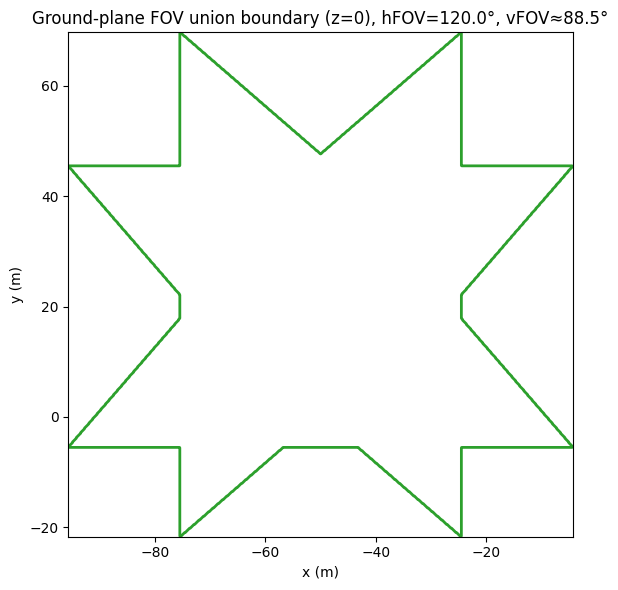

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# try shapely for an exact union; otherwise a raster fallback is used
try:
    from shapely.geometry import Polygon
    from shapely.ops import unary_union
    HAS_SHAPELY = True
except Exception:
    HAS_SHAPELY = False
from matplotlib.path import Path

# ---- camera + image params ----
W_px, H_px = 1280, 720
hFOV_deg = 120.0                       # CARLA camera "fov" (horizontal)
vFOV_deg = np.degrees(2*np.arctan(np.tan(np.radians(hFOV_deg/2.0)) * (H_px/W_px)))

# scene: plane z=0
Z_PLANE = 0.0

# your 4 cameras (x,y,z in meters; pitch,yaw in degrees; roll=0)
cams = [
    dict(x=-60, y=24, z=10, pitch=-60, yaw=0,   roll=0),
    dict(x=-40, y=24, z=10, pitch=-60, yaw=180, roll=0),
    dict(x=-50, y=30, z=10, pitch=-60, yaw=270, roll=0),
    dict(x=-50, y=10, z=10, pitch=-60, yaw=90,  roll=0),
]
# --- replace the rotation+footprint helpers with this ---

def Rz(a):
    a=np.radians(a); c,s=np.cos(a),np.sin(a)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])

def Ry(a):
    a=np.radians(a); c,s=np.cos(a),np.sin(a)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]])

def Rx(a):
    a=np.radians(a); c,s=np.cos(a),np.sin(a)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]])

def cam_dirs_boundary(hFOV_deg=120, H=720, W=1280, n_per_edge=64):
    vFOV_deg = np.degrees(2*np.arctan(np.tan(np.radians(hFOV_deg/2.0)) * (H/W)))
    th = np.tan(np.radians(hFOV_deg/2.0))
    tv = np.tan(np.radians(vFOV_deg/2.0))
    u_top    = np.linspace(-1, 1, n_per_edge); v_top    = np.full_like(u_top, -1)
    u_right  = np.full(n_per_edge, 1);        v_right  = np.linspace(-1, 1, n_per_edge)
    u_bottom = np.linspace( 1,-1, n_per_edge);v_bottom = np.full_like(u_bottom, 1)
    u_left   = np.full(n_per_edge, -1);       v_left   = np.linspace( 1,-1, n_per_edge)
    u = np.concatenate([u_top,u_right,u_bottom,u_left])
    v = np.concatenate([v_top,v_right,v_bottom,v_left])
    d = np.stack([np.ones_like(u), u*th, v*tv], axis=1)
    d = d / np.linalg.norm(d, axis=1, keepdims=True)
    return d  # [M,3]

def footprint_xy(cam, n_per_edge=96, hFOV_deg=120, H=720, W=1280):
    """
    Intersect camera frustum boundary rays with z=0 plane. Returns (K,2) XY.
    Uses Unreal/CARLA convention: yaw(Z) -> pitch(Y) -> roll(X) with pitch sign flipped.
    """
    # world rotation from camera: yaw ∘ (-pitch) ∘ roll
    R = Rz(cam["yaw"]) @ Ry(-cam["pitch"]) @ Rx(cam["roll"])
    O = np.array([cam["x"], cam["y"], cam["z"]], dtype=float)

    rays_cam = cam_dirs_boundary(hFOV_deg=hFOV_deg, H=H, W=W, n_per_edge=n_per_edge)  # [M,3]
    rays_w   = (R @ rays_cam.T).T
    dz = rays_w[:,2]
    valid = dz < -1e-6
    if not np.any(valid):
        return np.empty((0,2))
    t = -O[2] / dz[valid]
    P = O + rays_w[valid] * t[:,None]
    return P[:, :2]

# ---- build footprints ----
polys_xy = [footprint_xy(c, n_per_edge=96) for c in cams]     # list of (K_i,2)
# ---- union boundary only (no fill) ----
fig, ax = plt.subplots(figsize=(6,6))

if HAS_SHAPELY:
    polys = [Polygon(P) for P in polys_xy if len(P) > 0]
    if not polys:
        raise RuntimeError("No valid camera footprints. Check pitch/FOV.")
    U = unary_union(polys)

    def _plot_poly(poly):
        x, y = poly.exterior.xy
        ax.plot(x, y, color="tab:green", linewidth=2)
        # draw holes (if any) as dashed
        for ring in poly.interiors:
            xi, yi = ring.xy
            ax.plot(xi, yi, color="tab:green", linewidth=1, linestyle="--")

    if U.geom_type == "Polygon":
        _plot_poly(U)
    else:  # MultiPolygon
        for g in U.geometries:
            _plot_poly(g)
else:
    non_empty = [P for P in polys_xy if len(P) > 0]
    if not non_empty:
        raise RuntimeError("No valid camera footprints. Check pitch/FOV.")
    all_pts = np.vstack(non_empty)
    xmin,xmax = all_pts[:,0].min(), all_pts[:,0].max()
    ymin,ymax = all_pts[:,1].min(), all_pts[:,1].max()
    S = 800
    xs = np.linspace(xmin, xmax, S); ys = np.linspace(ymin, ymax, S)
    XX,YY = np.meshgrid(xs, ys)
    union_mask = np.zeros_like(XX, dtype=bool)
    for P in non_empty:
        union_mask |= Path(P).contains_points(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    # draw only the contour at 0.5 (boundary)
    ax.contour(XX, YY, union_mask.astype(float), levels=[0.5],
               colors="tab:green", linewidths=2)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title(f"Ground-plane FOV union boundary (z=0), hFOV={hFOV_deg}°, vFOV≈{vFOV_deg:.1f}°")
plt.tight_layout(); plt.show()

